# Modeling: NFL Run vs. Pass Prediction

**Predictive task.** Predict whether an NFL offense will run (0) or pass (1) *before the
offense lines up*, using only information available pre-lineup: down, distance, field
position, score, clock, timeouts, and the betting market. This is a binary classification
problem on tabular data.

**Why pre-lineup.** A defensive coordinator wants the call as early as possible, before the
offense breaks the huddle and shows its formation. Pre-snap formation cues such as shotgun
and no-huddle are extremely predictive, but they are only observable once the offense lines
up, so for a pre-lineup predictor they are effectively unavailable at prediction time. We
exclude them from the deployed model and instead measure, in an ablation, how much accuracy
they would add if we waited until after the lineup.

**Why it matters.** A model that reads only pre-lineup context tells us how predictable NFL
play-calling is from the situation alone, and which situations give away the most.

**Evaluation.** Time-based split to avoid leakage and to simulate forecasting a future
season. Train on 2022 and 2023, select models on 2024, and keep 2025 untouched for the final
test in `03_final_eval.ipynb`. For every model we report accuracy, precision, recall, F1, and
ROC-AUC, plus confusion matrices. The number to beat is the majority-class baseline (always
guess the more common class): if teams pass about 58% of the time, a useful model must clear
58%.

**Roadmap.**
1. Load and clean the data, engineer pre-lineup features (shared `src/features.py`).
2. Baselines: majority class, logistic regression (L2, then L1 vs L2), Gaussian Naive Bayes, linear SVM.
3. Advanced models: decision tree, random forest (bagging), LightGBM and XGBoost (boosting).
4. Model comparison across all five metrics.
5. Parameter sensitivity (validation curves) and a cross-validated grid search.
6. Ablation: how much would post-lineup formation cues, and pre-lineup team identity, add?
7. Feature importance and a PCA view of the feature space.
8. Save the deployed pre-lineup model for the demo and the final evaluation.

Each modeling choice: (OLS/Logistic, Regularization, SVM,
Naive Bayes/Decision Trees, Ensembles, PCA).

## 1. Setup, Data and Features

In [1]:
import os, sys, warnings, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# the shared feature module lives at the repo root (parent of notebooks/)
sys.path.insert(0, os.path.abspath(".."))
from src import features as F

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)
from sklearn.decomposition import PCA
import lightgbm as lgb
import xgboost as xgb
import joblib

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries loaded. LightGBM", lgb.__version__, "| XGBoost", xgb.__version__)

Libraries loaded. LightGBM 4.6.0 | XGBoost 3.2.0


In [2]:
DATA = "../data"
train_paths = [f"{DATA}/train/play_by_play_{y}.parquet" for y in (2022, 2023, 2024)]
raw = F.load_seasons(train_paths)
print(f"Raw run/pass plays (2022-2024): {len(raw):,}")

# build_xy with formation returns situation + formation columns; we slice as needed
X_all, y, season = F.build_xy(raw, include_formation=True)
print(f"After cleaning: {len(X_all):,} plays | pass rate = {y.mean():.3f}")
print(f"situation features = {len(F.SITUATION_FEATURES)} | full features = {len(F.FULL_FEATURES)}")
X_all.head()

Raw run/pass plays (2022-2024): 106,080
After cleaning: 105,681 plays | pass rate = 0.576
situation features = 29 | full features = 31


,down_1,down_2,down_3,down_4,ydstogo,yardline_100,score_differential,qtr,half_seconds_remaining,game_seconds_remaining,...,third_and_long,third_and_short,red_zone,trailing,leading,trailing_late,leading_late,score_time_pressure,shotgun,no_huddle
2,1,0,0,0,10.0,78.0,0.0,1.0,1796.0,3596.0,...,0,0,0,0,0,0,0,0.0,0,0
3,1,0,0,0,10.0,59.0,0.0,1.0,1769.0,3569.0,...,0,0,0,0,0,0,0,0.0,1,1
4,0,1,0,0,10.0,59.0,0.0,1.0,1765.0,3565.0,...,0,0,0,0,0,0,0,0.0,0,1
5,0,0,1,0,5.0,54.0,0.0,1.0,1741.0,3541.0,...,0,0,0,0,0,0,0,0.0,1,1
7,1,0,0,0,10.0,72.0,0.0,1.0,1722.0,3522.0,...,0,0,0,0,0,0,0,0.0,0,0


### Time-based train/validation split

We train on 2022-2023 and validate on 2024. A random split would let the model peek at
the same games' tendencies; splitting forward in time is the honest test of whether the
model generalizes to a future season, which is how it would actually be used. The 2025
season is never touched here.

In [3]:
tr_mask = season.isin([2022, 2023]).values
va_mask = (season == 2024).values

sit = F.SITUATION_FEATURES
Xtr, Xva = X_all.loc[tr_mask, sit], X_all.loc[va_mask, sit]
ytr, yva = y[tr_mask], y[va_mask]

print(f"Train: {Xtr.shape[0]:,} plays (2022-23) | pass rate {ytr.mean():.3f}")
print(f"Valid: {Xva.shape[0]:,} plays (2024)    | pass rate {yva.mean():.3f}")

Train: 70,778 plays (2022-23) | pass rate 0.578
Valid: 34,903 plays (2024)    | pass rate 0.570


### Evaluation helper

A single function computes the full metric suite for each model so the final comparison
is apples to apples.

In [4]:
results = []

def evaluate(name, y_true, y_pred, y_score, note=""):
    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "Note": note,
    }
    results.append(row)
    print(f"{name:<26s} acc={row['Accuracy']:.4f}  prec={row['Precision']:.4f}  "
          f"rec={row['Recall']:.4f}  F1={row['F1']:.4f}  AUC={row['ROC-AUC']:.4f}")
    return row

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4.2, 3.6))
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
                xticklabels=["run", "pass"], yticklabels=["run", "pass"], ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(title)
    plt.tight_layout(); plt.show()

## 2. Baselines

We start simple so every later model has something to beat. Each baseline maps to a
method from class.

### 2.0 Majority-class baseline

The simplest reasonable model: always predict the most frequent training class (pass).
Its accuracy is just the validation pass rate, and its scores carry no information, so
its ROC-AUC is 0.5.

In [5]:
majority_class = int(round(ytr.mean()))
maj_pred = np.full_like(yva, majority_class)
maj_score = np.full(len(yva), ytr.mean())   # constant score -> AUC 0.5
evaluate("Majority (always pass)", yva, maj_pred, maj_score, note="naive baseline")

Majority (always pass)     acc=0.5701  prec=0.5701  rec=1.0000  F1=0.7262  AUC=0.5000


{'Model': 'Majority (always pass)',
 'Accuracy': 0.5700656104059822,
 'Precision': 0.5700656104059822,
 'Recall': 1.0,
 'F1': 0.7261678832116788,
 'ROC-AUC': 0.5,
 'Note': 'naive baseline'}

### 2.1 Logistic Regression

The canonical linear classifier: a sigmoid over a weighted sum of features. Linear
models need features on comparable scales, so we put a `StandardScaler` and the
classifier in a `Pipeline`.

Logistic Regression (L2)   acc=0.6767  prec=0.7066  rec=0.7402  F1=0.7230  AUC=0.7385


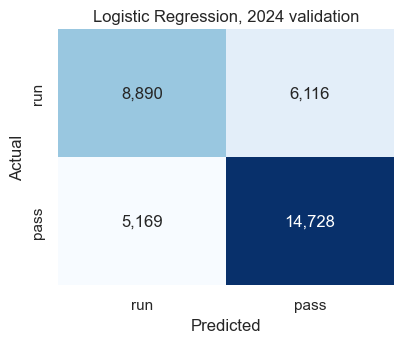

In [6]:
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_STATE)),
])
logreg.fit(Xtr, ytr)
pred = logreg.predict(Xva)
score = logreg.predict_proba(Xva)[:, 1]
evaluate("Logistic Regression (L2)", yva, pred, score, note="C=1.0, scaled")
plot_confusion(yva, pred, "Logistic Regression, 2024 validation")

### 2.2 Regularization: L1 vs L2
Ridge (L2), which shrinks all weights toward zero, with Lasso (L1),
which drives some weights exactly to zero and so performs feature selection. We fit both
at the same strength and compare validation accuracy and how many coefficients L1 zeroes
out.

penalty  val_accuracy  coeffs_zeroed  of_total
     L2      0.676675              0        29
     L1      0.676647              0        29


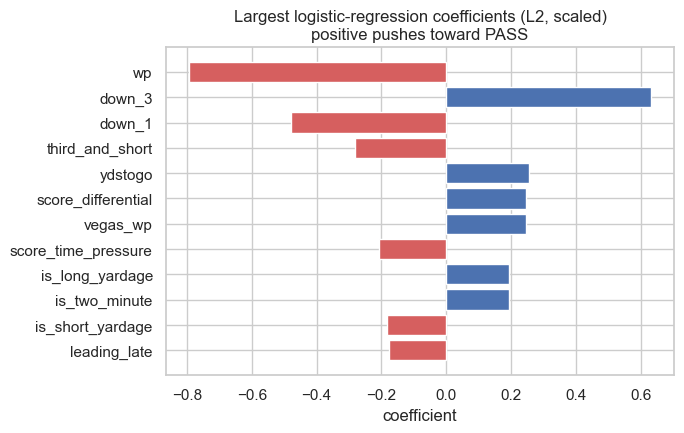

In [7]:
reg_rows = []
coef_table = pd.DataFrame({"feature": sit})
for pen, solver in [("l2", "lbfgs"), ("l1", "liblinear")]:
    m = Pipeline([("scaler", StandardScaler()),
                  ("clf", LogisticRegression(penalty=pen, solver=solver,
                                             C=1.0, max_iter=4000,
                                             random_state=RANDOM_STATE))]).fit(Xtr, ytr)
    coefs = m.named_steps["clf"].coef_.ravel()
    reg_rows.append({"penalty": pen.upper(),
                     "val_accuracy": accuracy_score(yva, m.predict(Xva)),
                     "coeffs_zeroed": int(np.sum(np.abs(coefs) < 1e-6)),
                     "of_total": len(coefs)})
    coef_table[pen.upper()] = coefs

print(pd.DataFrame(reg_rows).to_string(index=False))

# strongest L2 coefficients show the direction of each effect on pass probability
top = coef_table.reindex(coef_table["L2"].abs().sort_values(ascending=False).index).head(12)
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ["#d65f5f" if v < 0 else "#4c72b0" for v in top["L2"]]
ax.barh(top["feature"][::-1], top["L2"][::-1], color=colors[::-1])
ax.set_title("Largest logistic-regression coefficients (L2, scaled)\npositive pushes toward PASS")
ax.set_xlabel("coefficient"); plt.tight_layout(); plt.show()

### 2.3 Gaussian Naive Bayes 

Naive Bayes assumes features are conditionally independent given the class and, in the
Gaussian variant, that each numeric feature is normally distributed within a class. That
independence assumption is clearly false here (down, distance, and win probability are
correlated), so we expect Naive Bayes to trail logistic regression, which is a good
illustration

In [8]:
nb = GaussianNB().fit(Xtr, ytr)
pred = nb.predict(Xva)
score = nb.predict_proba(Xva)[:, 1]
evaluate("Gaussian Naive Bayes", yva, pred, score, note="independence assumption")

Gaussian Naive Bayes       acc=0.6392  prec=0.7140  rec=0.6125  F1=0.6594  AUC=0.7023


{'Model': 'Gaussian Naive Bayes',
 'Accuracy': 0.6392287195943042,
 'Precision': 0.7139844161930986,
 'Recall': 0.6125043976478867,
 'F1': 0.6593626575772331,
 'ROC-AUC': 0.702256848345415,
 'Note': 'independence assumption'}

### 2.4 Linear SVM 

A max-margin linear classifier with hinge loss. We use `LinearSVC` (liblinear), which
scales to 100k rows far better than a kernel SVM. `LinearSVC` has no `predict_proba`, so
we wrap it in `CalibratedClassifierCV` to recover scores for ROC-AUC.

In [9]:
svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", CalibratedClassifierCV(LinearSVC(C=1.0, dual=False,
                                             random_state=RANDOM_STATE), cv=3)),
]).fit(Xtr, ytr)
pred = svm.predict(Xva)
score = svm.predict_proba(Xva)[:, 1]
evaluate("Linear SVM", yva, pred, score, note="hinge loss, scaled")

Linear SVM                 acc=0.6751  prec=0.7024  rec=0.7464  F1=0.7237  AUC=0.7372


{'Model': 'Linear SVM',
 'Accuracy': 0.6751282124745723,
 'Precision': 0.702374195989406,
 'Recall': 0.7463939287329748,
 'F1': 0.7237153090811628,
 'ROC-AUC': 0.7372387209697047,
 'Note': 'hinge loss, scaled'}

## 3. Advanced Models

NFL play-calling is full of interactions (for example, 3rd-and-long while trailing late)
and non-linear thresholds that linear models capture only through hand-built features.
Tree-based models learn these automatically, which is why we expect them to win.

### 3.1 Decision Tree

A single greedy tree with Gini splits. On its own it overfits if grown unbounded, so we
cap the depth. It is the building block for the ensembles that follow.

In [10]:
dt = DecisionTreeClassifier(max_depth=8, min_samples_leaf=50,
                            random_state=RANDOM_STATE).fit(Xtr, ytr)
pred = dt.predict(Xva)
score = dt.predict_proba(Xva)[:, 1]
evaluate("Decision Tree", yva, pred, score, note="max_depth=8")

Decision Tree              acc=0.6905  prec=0.7681  rec=0.6547  F1=0.7069  AUC=0.7506


{'Model': 'Decision Tree',
 'Accuracy': 0.6904850585909521,
 'Precision': 0.7681014150943396,
 'Recall': 0.6547218173594009,
 'F1': 0.7068942127682666,
 'ROC-AUC': 0.7506085970898868,
 'Note': 'max_depth=8'}

### 3.2 Random Forest, bagging

Bagging trains many trees on bootstrap samples with random feature subsets and averages
them, which reduces variance. It is robust out of the box on tabular data.

Random Forest              acc=0.6975  prec=0.7466  rec=0.7106  F1=0.7281  AUC=0.7637


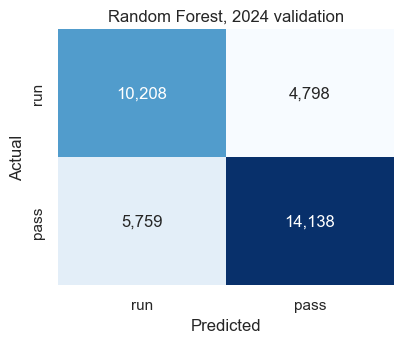

In [11]:
rf = RandomForestClassifier(n_estimators=300, max_depth=14, min_samples_leaf=20,
                            n_jobs=-1, random_state=RANDOM_STATE).fit(Xtr, ytr)
pred = rf.predict(Xva)
score = rf.predict_proba(Xva)[:, 1]
evaluate("Random Forest", yva, pred, score, note="300 trees, depth 14")
plot_confusion(yva, pred, "Random Forest, 2024 validation")

### 3.3 LightGBM, boosting

Boosting builds trees sequentially, each one correcting the previous ensemble's errors,
which reduces bias. LightGBM is a fast histogram-based implementation that grows trees leaf-wise
and is usually strong on tabular sports data.

LightGBM                   acc=0.6942  prec=0.7331  rec=0.7292  F1=0.7311  AUC=0.7641


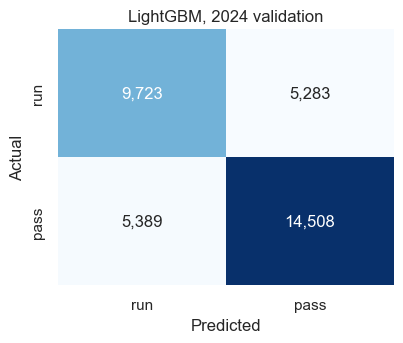

In [12]:
lgbm = lgb.LGBMClassifier(
    n_estimators=600, learning_rate=0.05, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)
lgbm.fit(Xtr, ytr)
pred = lgbm.predict(Xva)
score = lgbm.predict_proba(Xva)[:, 1]
evaluate("LightGBM", yva, pred, score, note="600 trees, lr=0.05")
plot_confusion(yva, pred, "LightGBM, 2024 validation")

### 3.4 XGBoost, boosting

XGBoost is the other widely used gradient-boosting library. It belongs to the same family
as LightGBM but grows trees level-wise by default rather than leaf-wise, so it tunes a
little differently. Including both lets us check whether the choice of boosting library
actually matters for this task. We use the histogram tree method for speed.

In [13]:
xgbst = xgb.XGBClassifier(
    n_estimators=600, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, tree_method="hist",
    eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
)
xgbst.fit(Xtr, ytr)
pred = xgbst.predict(Xva)
score = xgbst.predict_proba(Xva)[:, 1]
evaluate("XGBoost", yva, pred, score, note="600 trees, depth 6")

XGBoost                    acc=0.6938  prec=0.7297  rec=0.7353  F1=0.7325  AUC=0.7628


{'Model': 'XGBoost',
 'Accuracy': 0.6938085551385268,
 'Precision': 0.7296758104738155,
 'Recall': 0.7352867266422074,
 'F1': 0.7324705234435627,
 'ROC-AUC': 0.7627542003921823,
 'Note': '600 trees, depth 6'}

## 4. Model Comparison

All five metrics for every model on the 2024 validation season.

In [14]:
res_df = (pd.DataFrame(results)
          .drop_duplicates(subset="Model", keep="last")
          .sort_values("Accuracy", ascending=False)
          .reset_index(drop=True))
baseline_acc = yva.mean()
print(f"Majority-class baseline accuracy = {baseline_acc:.4f}\n")
res_df[["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "Note"]].round(4)

Majority-class baseline accuracy = 0.5701



,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Note
0,Random Forest,0.6975,0.7466,0.7106,0.7281,0.7637,"300 trees, depth 14"
1,LightGBM,0.6942,0.7331,0.7292,0.7311,0.7641,"600 trees, lr=0.05"
2,XGBoost,0.6938,0.7297,0.7353,0.7325,0.7628,"600 trees, depth 6"
3,Decision Tree,0.6905,0.7681,0.6547,0.7069,0.7506,max_depth=8
4,Logistic Regression (L2),0.6767,0.7066,0.7402,0.7230,0.7385,"C=1.0, scaled"
5,Linear SVM,0.6751,0.7024,0.7464,0.7237,0.7372,"hinge loss, scaled"
6,Gaussian Naive Bayes,0.6392,0.7140,0.6125,0.6594,0.7023,independence assumption
7,Majority (always pass),0.5701,0.5701,1.0000,0.7262,0.5000,naive baseline


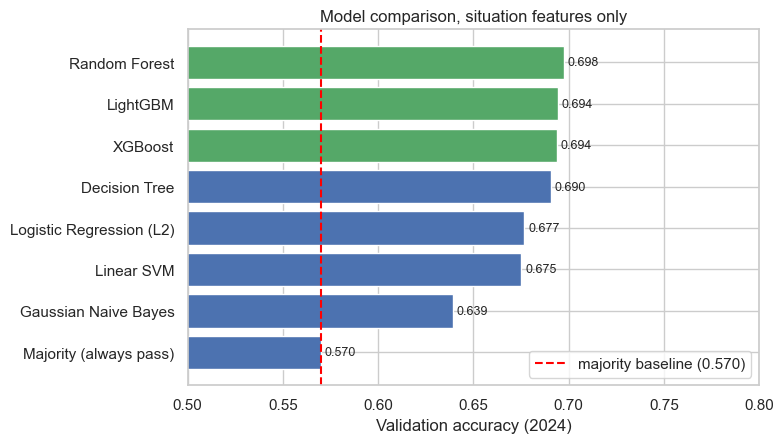

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.6))
order = res_df.sort_values("Accuracy")
colors = ["#55a868" if m in ("Random Forest", "LightGBM", "XGBoost") else "#4c72b0"
          for m in order["Model"]]
ax.barh(order["Model"], order["Accuracy"], color=colors)
ax.axvline(baseline_acc, color="red", ls="--", lw=1.5,
           label=f"majority baseline ({baseline_acc:.3f})")
ax.set_xlim(0.5, max(0.8, order["Accuracy"].max() + 0.03))
ax.set_xlabel("Validation accuracy (2024)")
ax.set_title("Model comparison, situation features only")
for y_, v in zip(range(len(order)), order["Accuracy"]):
    ax.text(v + 0.002, y_, f"{v:.3f}", va="center", fontsize=9)
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

## 5. Parameter Sensitivity

We sweep one hyper-parameter at a time and plot train versus validation accuracy. The
gap between the curves is the bias-variance story when train accuracy
keeps rising while validation flattens or falls, the model is overfitting.

### 5.1 Logistic Regression: regularization strength C

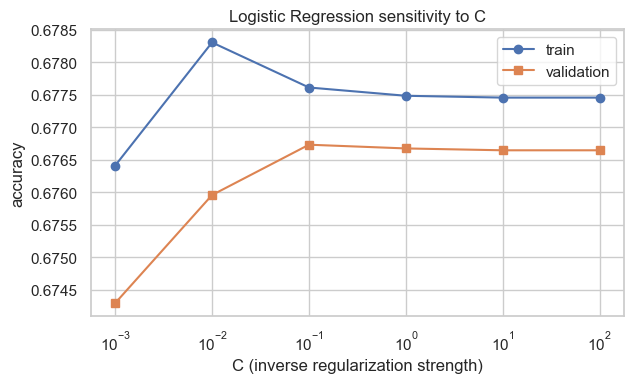

Best C: 0.1 -> val acc 0.6767


In [16]:
C_grid = [0.001, 0.01, 0.1, 1, 10, 100]
tr_acc, va_acc = [], []
for C in C_grid:
    m = Pipeline([("scaler", StandardScaler()),
                  ("clf", LogisticRegression(C=C, max_iter=4000,
                                             random_state=RANDOM_STATE))]).fit(Xtr, ytr)
    tr_acc.append(accuracy_score(ytr, m.predict(Xtr)))
    va_acc.append(accuracy_score(yva, m.predict(Xva)))

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.semilogx(C_grid, tr_acc, "o-", label="train")
ax.semilogx(C_grid, va_acc, "s-", label="validation")
ax.set_xlabel("C (inverse regularization strength)"); ax.set_ylabel("accuracy")
ax.set_title("Logistic Regression sensitivity to C"); ax.legend(); plt.tight_layout(); plt.show()
print("Best C:", C_grid[int(np.argmax(va_acc))], "-> val acc", round(max(va_acc), 4))

### 5.2 Random Forest: max_depth and n_estimators

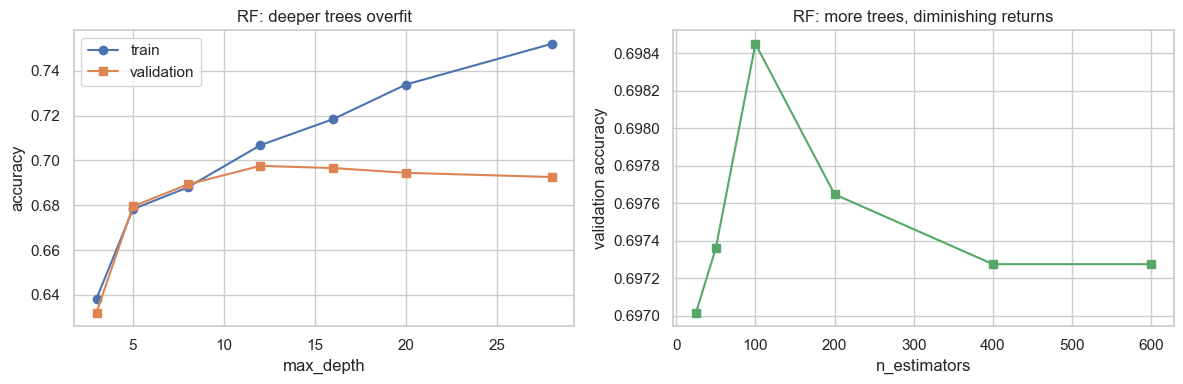

Best depth: 12 -> val acc 0.6976


In [17]:
depth_grid = [3, 5, 8, 12, 16, 20, 28]
tr_acc, va_acc = [], []
for d in depth_grid:
    m = RandomForestClassifier(n_estimators=200, max_depth=d, min_samples_leaf=20,
                               n_jobs=-1, random_state=RANDOM_STATE).fit(Xtr, ytr)
    tr_acc.append(accuracy_score(ytr, m.predict(Xtr)))
    va_acc.append(accuracy_score(yva, m.predict(Xva)))

n_grid = [25, 50, 100, 200, 400, 600]
n_va = []
for n in n_grid:
    m = RandomForestClassifier(n_estimators=n, max_depth=14, min_samples_leaf=20,
                               n_jobs=-1, random_state=RANDOM_STATE).fit(Xtr, ytr)
    n_va.append(accuracy_score(yva, m.predict(Xva)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(depth_grid, tr_acc, "o-", label="train")
axes[0].plot(depth_grid, va_acc, "s-", label="validation")
axes[0].set_xlabel("max_depth"); axes[0].set_ylabel("accuracy")
axes[0].set_title("RF: deeper trees overfit"); axes[0].legend()
axes[1].plot(n_grid, n_va, "s-", color="#55a868")
axes[1].set_xlabel("n_estimators"); axes[1].set_ylabel("validation accuracy")
axes[1].set_title("RF: more trees, diminishing returns")
plt.tight_layout(); plt.show()
print("Best depth:", depth_grid[int(np.argmax(va_acc))], "-> val acc", round(max(va_acc), 4))

### 5.3 LightGBM: learning_rate and num_leaves

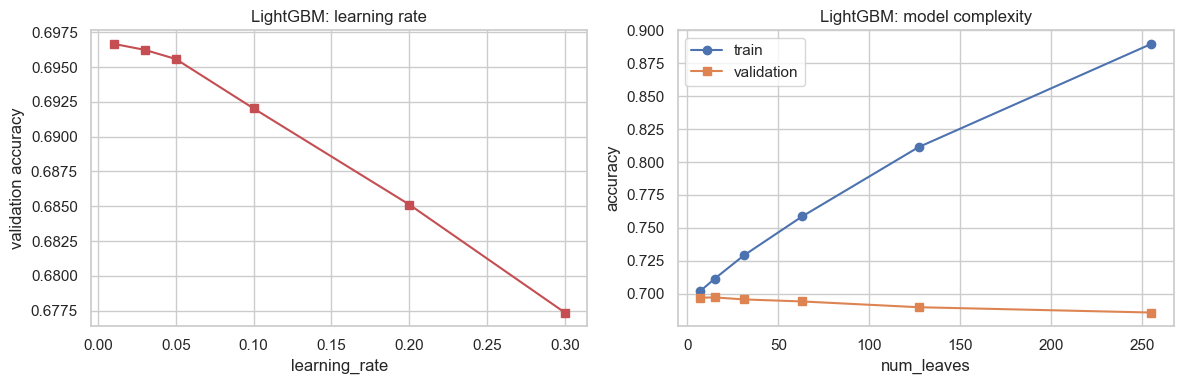

Best lr: 0.01 -> val acc 0.6967


In [18]:
lr_grid = [0.01, 0.03, 0.05, 0.1, 0.2, 0.3]
lr_va = []
for lr in lr_grid:
    m = lgb.LGBMClassifier(n_estimators=400, learning_rate=lr, num_leaves=31,
                           subsample=0.8, colsample_bytree=0.8,
                           random_state=RANDOM_STATE, n_jobs=-1, verbose=-1).fit(Xtr, ytr)
    lr_va.append(accuracy_score(yva, m.predict(Xva)))

leaf_grid = [7, 15, 31, 63, 127, 255]
leaf_tr, leaf_va = [], []
for nl in leaf_grid:
    m = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=nl,
                           subsample=0.8, colsample_bytree=0.8,
                           random_state=RANDOM_STATE, n_jobs=-1, verbose=-1).fit(Xtr, ytr)
    leaf_tr.append(accuracy_score(ytr, m.predict(Xtr)))
    leaf_va.append(accuracy_score(yva, m.predict(Xva)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(lr_grid, lr_va, "s-", color="#c44e52")
axes[0].set_xlabel("learning_rate"); axes[0].set_ylabel("validation accuracy")
axes[0].set_title("LightGBM: learning rate")
axes[1].plot(leaf_grid, leaf_tr, "o-", label="train")
axes[1].plot(leaf_grid, leaf_va, "s-", label="validation")
axes[1].set_xlabel("num_leaves"); axes[1].set_ylabel("accuracy")
axes[1].set_title("LightGBM: model complexity"); axes[1].legend()
plt.tight_layout(); plt.show()
print("Best lr:", lr_grid[int(np.argmax(lr_va))], "-> val acc", round(max(lr_va), 4))

### 5.4 Cross-validated grid search on LightGBM

The sweeps above tune one knob at a time on a single split. Here we run a 5-fold
cross-validated grid search over the main LightGBM knobs to pick a final configuration.

In [19]:
param_grid = {
    "n_estimators": [400, 800],
    "learning_rate": [0.03, 0.05],
    "num_leaves": [31, 63],
    "min_child_samples": [20, 50],
}
base = lgb.LGBMClassifier(subsample=0.8, colsample_bytree=0.8,
                          random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
gs = GridSearchCV(base, param_grid, scoring="accuracy", cv=cv, n_jobs=-1, verbose=0)
t0 = time.time(); gs.fit(Xtr, ytr)
print(f"GridSearchCV done in {time.time()-t0:.1f}s over {len(gs.cv_results_['params'])} configs")
print("Best CV accuracy:", round(gs.best_score_, 4))
print("Best params:", gs.best_params_)
best_lgbm = gs.best_estimator_
va_pred = best_lgbm.predict(Xva); va_score = best_lgbm.predict_proba(Xva)[:, 1]
evaluate("LightGBM (tuned)", yva, va_pred, va_score, note="5-fold GridSearchCV")

GridSearchCV done in 266.2s over 16 configs
Best CV accuracy: 0.6968
Best params: {'learning_rate': 0.03, 'min_child_samples': 50, 'n_estimators': 400, 'num_leaves': 31}
LightGBM (tuned)           acc=0.6962  prec=0.7362  rec=0.7278  F1=0.7320  AUC=0.7664


{'Model': 'LightGBM (tuned)',
 'Accuracy': 0.6961579233876745,
 'Precision': 0.736173241154941,
 'Recall': 0.7278484193597025,
 'F1': 0.7319871616669615,
 'ROC-AUC': 0.7663748877825693,
 'Note': '5-fold GridSearchCV'}

## 6. Ablation: the value of information beyond the pre-lineup situation

The deployed model is pre-lineup, so it uses situation features only. Two kinds of extra
information are worth quantifying even though the deployed model does not use the first:

* Post-lineup formation cues (shotgun, no-huddle), which a defender sees only once the
  offense lines up. They are very informative: in our data teams pass 69% of the time from
  shotgun versus 30% otherwise. This ablation shows how much accuracy a defense would gain by
  waiting until after the lineup.
* Team identity (section 6.2), which is known pre-lineup but turns out to add little.

We re-run the same models with formation added on top of the pre-lineup situation features
and report all five metrics for both feature sets.

In [20]:
Xtr_full = X_all.loc[tr_mask, F.FULL_FEATURES]
Xva_full = X_all.loc[va_mask, F.FULL_FEATURES]

def make_model(name):
    if name == "Logistic Regression":
        return Pipeline([("scaler", StandardScaler()),
            ("clf", LogisticRegression(C=1.0, max_iter=2000, random_state=RANDOM_STATE))])
    if name == "Random Forest":
        return RandomForestClassifier(n_estimators=300, max_depth=14, min_samples_leaf=20,
            n_jobs=-1, random_state=RANDOM_STATE)
    if name == "LightGBM":
        return lgb.LGBMClassifier(n_estimators=600, learning_rate=0.05, num_leaves=31,
            subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    if name == "XGBoost":
        return xgb.XGBClassifier(n_estimators=600, learning_rate=0.05, max_depth=6,
            subsample=0.8, colsample_bytree=0.8, tree_method="hist", eval_metric="logloss",
            random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)

def metric_dict(y_true, y_pred, y_score):
    return {"Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0),
            "F1": f1_score(y_true, y_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_true, y_score)}

abl = []
feature_sets = {"situation": (Xtr, Xva), "situation + formation": (Xtr_full, Xva_full)}
for name in ["Logistic Regression", "Random Forest", "LightGBM", "XGBoost"]:
    for label, (Xt, Xv) in feature_sets.items():
        m = make_model(name).fit(Xt, ytr)
        row = {"Model": name, "Features": label}
        row.update(metric_dict(yva, m.predict(Xv), m.predict_proba(Xv)[:, 1]))
        abl.append(row)
abl_df = pd.DataFrame(abl)
abl_df.round(4)

,Model,Features,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,situation,0.6767,0.7066,0.7402,0.7230,0.7385
1,Logistic Regression,situation + formation,0.7041,0.7099,0.8132,0.7581,0.7659
2,Random Forest,situation,0.6975,0.7466,0.7106,0.7281,0.7637
3,Random Forest,situation + formation,0.7137,0.7241,0.8041,0.7620,0.7846
4,LightGBM,situation,0.6942,0.7331,0.7292,0.7311,0.7641
5,LightGBM,situation + formation,0.7151,0.7339,0.7849,0.7585,0.7851
6,XGBoost,situation,0.6938,0.7297,0.7353,0.7325,0.7628
7,XGBoost,situation + formation,0.7132,0.7327,0.7825,0.7568,0.7834


Features             situation  situation + formation    Lift
Model                                                        
LightGBM                0.6942                 0.7151  0.0209
Logistic Regression     0.6767                 0.7041  0.0274
Random Forest           0.6975                 0.7137  0.0162
XGBoost                 0.6938                 0.7132  0.0194


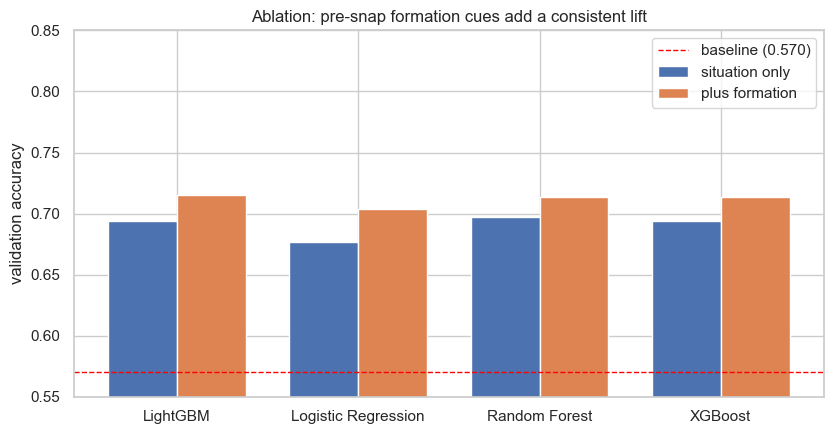

In [21]:
# accuracy lift from adding the two formation cues
pivot = abl_df.pivot(index="Model", columns="Features", values="Accuracy")
pivot["Lift"] = pivot["situation + formation"] - pivot["situation"]
print(pivot.round(4).to_string())

models = pivot.index.tolist()
x = np.arange(len(models)); w = 0.38
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.bar(x - w/2, pivot["situation"], w, label="situation only", color="#4c72b0")
ax.bar(x + w/2, pivot["situation + formation"], w, label="plus formation", color="#dd8452")
ax.axhline(baseline_acc, color="red", ls="--", lw=1, label=f"baseline ({baseline_acc:.3f})")
ax.set_xticks(x); ax.set_xticklabels(models); ax.set_ylim(0.55, 0.85)
ax.set_ylabel("validation accuracy")
ax.set_title("Ablation: pre-snap formation cues add a consistent lift")
ax.legend(); plt.tight_layout(); plt.show()

### 6.2 Adding team identity (historical-rate encoding)

Team identity is known before the offense lines up, so unlike formation it is a fair
pre-lineup feature. Teams differ in how often they pass: over 2022-2024 offensive pass rate
ranges from about 49% (most run-heavy) to 65% (most pass-heavy). We encode this without
leakage by computing each team's historical pass rate on the training seasons only, then
mapping it onto later seasons. `posteam_pass_rate` is the offense's tendency and
`defteam_pass_rate_faced` is how often the defenses' opponents pass. We add these on top of
the pre-lineup situation features and report all five metrics.

In [22]:
# team identity is pre-lineup; encode it as leakage-safe historical pass rates
work_team = F.engineer(F.clean(raw))
tr_t = work_team["season"].isin([2022, 2023]).values
va_t = (work_team["season"] == 2024).values

rates = F.fit_team_rates(work_team[tr_t])          # fit on training seasons only
work_team = F.add_team_features(work_team, rates)
ytr_t, yva_t = work_team[F.TARGET][tr_t], work_team[F.TARGET][va_t]

team_sets = {"situation": F.SITUATION_FEATURES,
             "+ team identity": F.SITUATION_FEATURES + F.TEAM_FEATURES}
team_rows = []
for label, feats in team_sets.items():
    m = make_model("LightGBM").fit(work_team.loc[tr_t, feats], ytr_t)
    Xv = work_team.loc[va_t, feats]
    row = {"Features": label}
    row.update(metric_dict(yva_t, m.predict(Xv), m.predict_proba(Xv)[:, 1]))
    team_rows.append(row)
team_tbl = pd.DataFrame(team_rows).set_index("Features").round(4)
print(team_tbl.to_string())
print(f"\nAccuracy lift from team identity (2024 validation): "
      f"+{team_tbl['Accuracy'].iloc[1] - team_tbl['Accuracy'].iloc[0]:.4f}")

                 Accuracy  Precision  Recall      F1  ROC-AUC
Features                                                     
situation          0.6942     0.7331  0.7292  0.7311   0.7641
+ team identity    0.6991     0.7354  0.7376  0.7365   0.7689

Accuracy lift from team identity (2024 validation): +0.0049


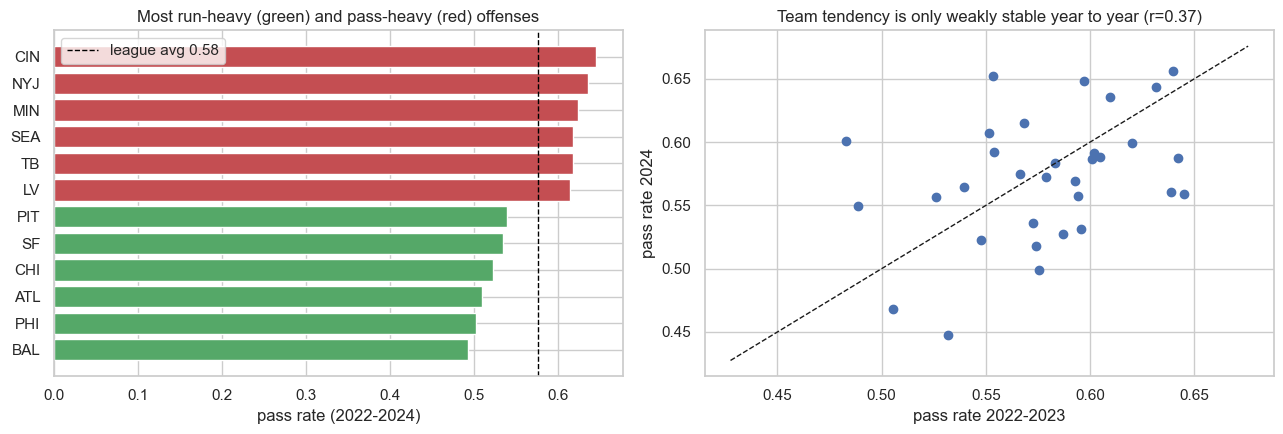

In [23]:
# team tendencies and how stable they are across seasons
p = work_team[F.TARGET].astype(int)
off = p.groupby(work_team["posteam"]).mean().sort_values()
a = p[tr_t].groupby(work_team.loc[tr_t, "posteam"]).mean()
b = p[va_t].groupby(work_team.loc[va_t, "posteam"]).mean()
stab = pd.concat([a, b], axis=1, keys=["y2223", "y2024"]).dropna()
r = stab["y2223"].corr(stab["y2024"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ends = pd.concat([off.head(6), off.tail(6)])
axes[0].barh(ends.index, ends.values, color=["#55a868"]*6 + ["#c44e52"]*6)
axes[0].axvline(p.mean(), color="black", ls="--", lw=1, label=f"league avg {p.mean():.2f}")
axes[0].set_xlabel("pass rate (2022-2024)")
axes[0].set_title("Most run-heavy (green) and pass-heavy (red) offenses"); axes[0].legend()
axes[1].scatter(stab["y2223"], stab["y2024"], color="#4c72b0")
lims = [stab.values.min() - 0.02, stab.values.max() + 0.02]
axes[1].plot(lims, lims, "k--", lw=1)
axes[1].set_xlabel("pass rate 2022-2023"); axes[1].set_ylabel("pass rate 2024")
axes[1].set_title(f"Team tendency is only weakly stable year to year (r={r:.2f})")
plt.tight_layout(); plt.show()

## 7. Interpretation

### 7.1 Feature importance

Which variables drive the deployed pre-lineup model? We read gain-based importances from a
LightGBM fit on the situation feature set.

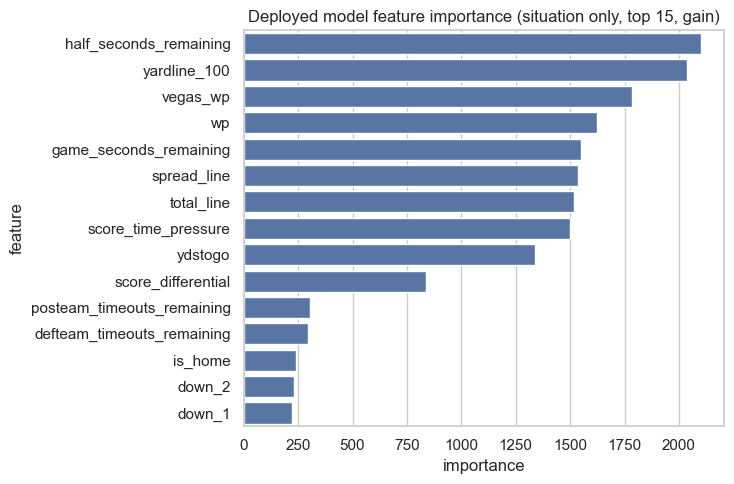

,feature,importance
0,half_seconds_remaining,2102
1,yardline_100,2036
2,vegas_wp,1785
3,wp,1625
4,game_seconds_remaining,1551
5,spread_line,1536
6,total_line,1520
7,score_time_pressure,1501
8,ydstogo,1340
9,score_differential,839


In [24]:
imp_model = lgb.LGBMClassifier(n_estimators=600, learning_rate=0.05, num_leaves=31,
        subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
        n_jobs=-1, verbose=-1).fit(Xtr, ytr)
imp = (pd.DataFrame({"feature": F.SITUATION_FEATURES, "importance": imp_model.feature_importances_})
       .sort_values("importance", ascending=False).head(15))
fig, ax = plt.subplots(figsize=(7.5, 5))
sns.barplot(data=imp, y="feature", x="importance", color="#4c72b0", ax=ax)
ax.set_title("Deployed model feature importance (situation only, top 15, gain)")
plt.tight_layout(); plt.show()
imp.reset_index(drop=True)

### 7.2 PCA view of the feature space

PCA is unsupervised, but projecting the standardized situation features onto their first
two principal components shows how separable run and pass plays are linearly. Heavy
overlap here is the reason non-linear tree ensembles beat the linear baselines.

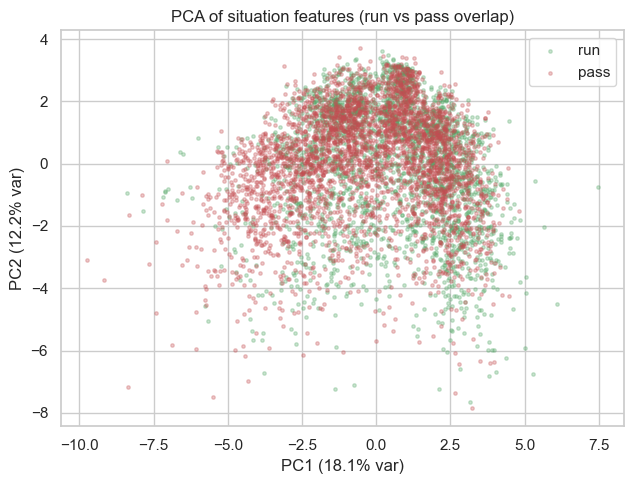

Variance explained by first 2 PCs: 0.303


In [25]:
samp = np.random.RandomState(RANDOM_STATE).choice(len(Xtr), size=6000, replace=False)
Xs = StandardScaler().fit_transform(Xtr.iloc[samp])
pcs = PCA(n_components=2, random_state=RANDOM_STATE).fit(Xs)
Z = pcs.transform(Xs)
fig, ax = plt.subplots(figsize=(6.5, 5))
for cls, color, lab in [(0, "#55a868", "run"), (1, "#c44e52", "pass")]:
    m = ytr.iloc[samp].values == cls
    ax.scatter(Z[m, 0], Z[m, 1], s=6, alpha=0.3, c=color, label=lab)
ax.set_xlabel(f"PC1 ({pcs.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pcs.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("PCA of situation features (run vs pass overlap)"); ax.legend()
plt.tight_layout(); plt.show()
print("Variance explained by first 2 PCs:", round(pcs.explained_variance_ratio_[:2].sum(), 3))

## 8. Save the Deployed Model

The deployed model is the pre-lineup, situation-only LightGBM, refit on all of 2022-2024.
We save it as the submitted model used by `03_final_eval.ipynb` and the demo. For the demo's
optional after-lineup comparison and the ablation, we also save a secondary model that adds
the post-lineup formation cues. We store both, the feature lists, and the tuned
hyper-parameters so the artifact is reproducible.

In [26]:
os.makedirs("../models", exist_ok=True)
final_params = dict(gs.best_params_)

# deployed model: PRE-LINEUP, situation features only, refit on all of 2022-2024
deployed_model = lgb.LGBMClassifier(subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, **final_params)
deployed_model.fit(X_all[F.SITUATION_FEATURES], y)

# secondary model: also uses post-lineup formation cues. Kept only for the demo's
# after-lineup comparison and the ablation; this is not the submitted model.
formation_model = lgb.LGBMClassifier(subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, **final_params)
formation_model.fit(X_all[F.FULL_FEATURES], y)

artifact = {
    "model": deployed_model,
    "features": F.SITUATION_FEATURES,
    "formation_model": formation_model,
    "formation_features": F.FULL_FEATURES,
    "situation_features": F.SITUATION_FEATURES,
    "params": final_params,
    "train_seasons": [2022, 2023, 2024],
    "baseline_pass_rate": float(y.mean()),
}
joblib.dump(artifact, "../models/lgbm_runpass.joblib")
print("Saved -> models/lgbm_runpass.joblib")
print("Deployed model: pre-lineup (situation only), refit on", len(X_all), "plays.")

Saved -> models/lgbm_runpass.joblib
Deployed model: pre-lineup (situation only), refit on 105681 plays.


## 9. Takeaways

Everything beats the 58% majority baseline. Even logistic regression on pre-lineup game state
lands well above it, so NFL play-calling is predictable from the situation alone.

Tree ensembles win. Random forest (bagging, lower variance) and the two boosting libraries
(LightGBM and XGBoost, lower bias) top the linear baselines because play-calling hinges on
feature interactions that linear models capture only through hand-built terms. LightGBM and
XGBoost finish within a fraction of a point of each other.

Naive Bayes lags, because its conditional-independence assumption is
false for these correlated game-state features.

Parameter sensitivity shows the bias-variance trade-off directly: deep trees and large
num_leaves overfit, and regularization (C, learning rate) controls it.

Post-lineup formation cues would add roughly two accuracy points, but they are only
observable after the offense lines up, so a pre-lineup predictor cannot use them. We report
that gain as an ablation and keep the cues out of the deployed model. Team identity, although
available pre-lineup, adds very little and is unstable across seasons.

The deployed model is the pre-lineup situation-only LightGBM, saved for the 2025 final
evaluation and the demo.